# import modules

In [108]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Loading datasets

In [109]:
import json
import pandas as pd
from pathlib import Path

directory = Path("/Users/nouhailaimaneabbassi/Desktop/Pacing/app/data/cleaned_data/extranat/competitions_per_type")

data = []

# Charger tous les JSON
for file in directory.rglob("*.json"):
    with open(file, "r", encoding="utf-8") as f:
        data.append(json.load(f))

# Aplatir les données : 1 ligne par performance
rows = []
for comp in data:
    for epreuve in comp.get("epreuves", []):
        for perf in epreuve.get("performances", []):

            # S'assurer que 'swimmer' est toujours une liste
            swimmers = perf.get("swimmer", [])
            if isinstance(swimmers, dict):
                swimmers = [swimmers]

            # Construire la ligne
            row = {
                "Meet": comp.get("Meet"),
                "SwimDate": comp.get("SwimDate"),
                "Location": comp.get("location"),
                "Country": comp.get("Country"),
                "Event": epreuve.get("Event"),
                "Distance": epreuve.get("Distance"),
                "Stroke": epreuve.get("Stroke"),
                "Course": epreuve.get("Course"),
                "PoolLength": epreuve.get("PoolLength"),
                "Tour": epreuve.get("tour"),
                "Rank": perf.get("Rank"),
                "Club": perf.get("club"),
                "points": perf.get("points"),
                "mpp": perf.get("mpp"),
                "mpp_date": perf.get("mpp_date"),
                "SwimTime": perf.get("SwimTime"),
                "SwimTimeSeconds": perf.get("SwimTimeSeconds"),
                "Status": perf.get("Status"),
                "Speed": perf.get("Speed"),
                "swimmer": swimmers,  # garder la liste brute
                "splits": perf.get("splits", [])
            }

            rows.append(row)

df = pd.DataFrame(rows)

# Vérifier le résultat
print(df.head())
print("Nombre de SwimTime :", df['SwimTime'].notna().sum())

                                            Meet    SwimDate   Location  \
0  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
1  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
2  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
3  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
4  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   

  Country       Event  Distance     Stroke Course  PoolLength    Tour  ...  \
0     FRA  200 FR SCM       200  Freestyle    SCM          25  Séries  ...   
1     FRA  200 FR SCM       200  Freestyle    SCM          25  Séries  ...   
2     FRA  200 FR SCM       200  Freestyle    SCM          25  Séries  ...   
3     FRA  200 FR SCM       200  Freestyle    SCM          25  Séries  ...   
4     FRA  200 FR SCM       200  Freestyle    SCM          25  Séries  ...   

             Club points       mpp    mpp_date  SwimTime SwimTimeSeconds  \
0  M

In [110]:
print(df.columns)

Index(['Meet', 'SwimDate', 'Location', 'Country', 'Event', 'Distance',
       'Stroke', 'Course', 'PoolLength', 'Tour', 'Rank', 'Club', 'points',
       'mpp', 'mpp_date', 'SwimTime', 'SwimTimeSeconds', 'Status', 'Speed',
       'swimmer', 'splits'],
      dtype='str')


In [111]:
print("Nombre de lignes :", df.shape)  # (762371, 22)

Nombre de lignes : (762371, 21)


In [112]:
nb_swimtime_vides = df['SwimTime'].isna().sum()
print("Nombre de SwimTime vides :", nb_swimtime_vides)
# Nombre de SwimTime non vides
nb_swimtime = df['SwimTime'].notna().sum()
print("Nombre de SwimTime présents :", nb_swimtime)

Nombre de SwimTime vides : 0
Nombre de SwimTime présents : 762371


In [114]:
print("Nombre de lignes :", len(df)) # 762371

Nombre de lignes : 762371


In [115]:
# Compter le nombre de SwimTime non vides
nombre_swimtime = df['SwimTime'].notna().sum()
print("Nombre de SwimTime :", nombre_swimtime)

Nombre de SwimTime : 762371


In [116]:
import pprint
pprint.pprint(df.iloc[383]["swimmer"])

[{'Gender': 'F',
  'Name': 'Rey Mia',
  'Nationality': 'FRA',
  'Year_of_birth': 2013},
 {'Gender': 'F',
  'Name': 'Lebas Romane Adèle',
  'Nationality': 'FRA',
  'Year_of_birth': 2013},
 {'Gender': 'F',
  'Name': 'Hoareau Miotysoa',
  'Nationality': 'FRA',
  'Year_of_birth': 2012},
 {'Gender': 'F',
  'Name': 'Daïca Dalleau Apryl',
  'Nationality': 'FRA',
  'Year_of_birth': 2012}]


In [117]:
print(df.iloc[383])

Meet                   Phase finale Coupe de France des Départements
SwimDate                                                  2025-12-22
Location                                                   DUNKERQUE
Country                                                          FRA
Event                                                       4 MD SCM
Distance                                                        2016
Stroke                                                           NaN
Course                                                           SCM
PoolLength                                                        25
Tour                                                          Séries
Rank                                                             1.0
Club                                                      LA RÉUNION
points                                                        1080.0
mpp                                                              NaN
mpp_date                          

In [118]:
import pprint
pprint.pprint(df.iloc[383]["splits"])

[{'SplitDistance': '50 m',
  'cumul': '33.70',
  'cumul_seconds': 33.7,
  'split': '00:33.70',
  'split_seconds': 33.7},
 {'SplitDistance': '100 m',
  'cumul': '1:11.40',
  'cumul_seconds': 71.4,
  'split': '00:37.70',
  'split_seconds': 37.7},
 {'SplitDistance': '150 m',
  'cumul': '1:43.45',
  'cumul_seconds': 103.45,
  'split': '00:32.05',
  'split_seconds': 32.05},
 {'SplitDistance': '200 m',
  'cumul': '2:12.02',
  'cumul_seconds': 132.02,
  'split': '00:28.57',
  'split_seconds': 28.57}]


In [119]:
print(df.columns)

Index(['Meet', 'SwimDate', 'Location', 'Country', 'Event', 'Distance',
       'Stroke', 'Course', 'PoolLength', 'Tour', 'Rank', 'Club', 'points',
       'mpp', 'mpp_date', 'SwimTime', 'SwimTimeSeconds', 'Status', 'Speed',
       'swimmer', 'splits'],
      dtype='str')


In [120]:
swim_times = df["SwimTimeSeconds"]
swim_times = swim_times[swim_times == 0]
print(swim_times)

182140    0.0
664830    0.0
Name: SwimTimeSeconds, dtype: float64


# Histogram of swim times

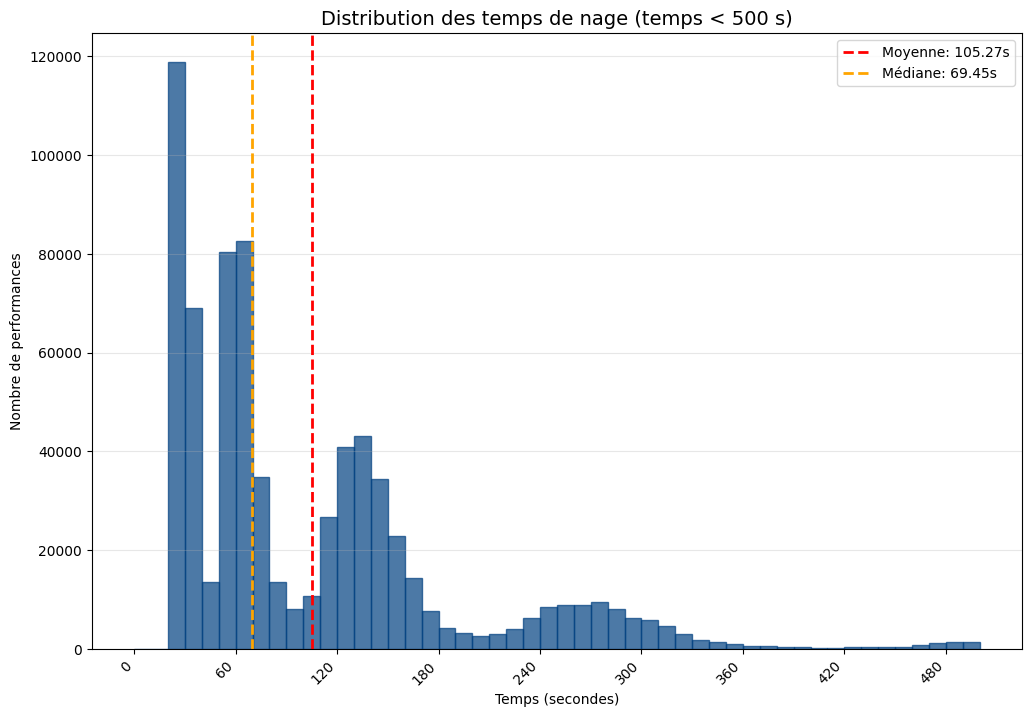

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

swim_times = df["SwimTimeSeconds"]
swim_times = swim_times[swim_times < 500]

fig, ax = plt.subplots(figsize=(12,8))
ax.hist(swim_times, bins=50, color="#004080", edgecolor="#004080", alpha=0.7)

mean_time = np.mean(swim_times)
median_time = np.median(swim_times)

ax.axvline(mean_time, color='red', linestyle='dashed', linewidth=2, label=f'Moyenne: {mean_time:.2f}s')
ax.axvline(median_time, color='orange', linestyle='dashed', linewidth=2, label=f'Médiane: {median_time:.2f}s')

ax.set_title("Distribution des temps de nage (temps < 500 s)", fontsize=14)
ax.set_xlabel("Temps (secondes)")
ax.set_ylabel("Nombre de performances")
ax.legend()

ax.grid(axis='y', alpha=0.3)

ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))  
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")  

plt.show()

# Histogram with Kernel Density Estimate (KDE)

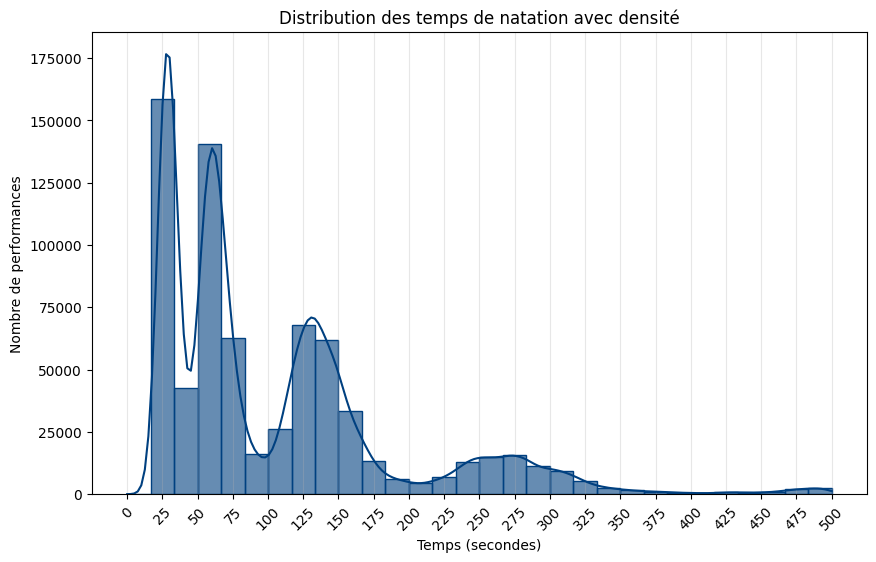

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

swim_times = df["SwimTimeSeconds"].dropna()
swim_times = swim_times[swim_times < 500]

plt.figure(figsize=(10,6))

sns.histplot(swim_times, bins=30, kde=True,
             color="#004080", edgecolor="#004080", alpha=0.6)

plt.title("Distribution des temps de natation avec densité")
plt.xlabel("Temps (secondes)")
plt.ylabel("Nombre de performances")

plt.xticks(np.arange(0, 501, 25), rotation=45)
plt.grid(axis="x", alpha=0.3)

plt.show()

# Boxplot

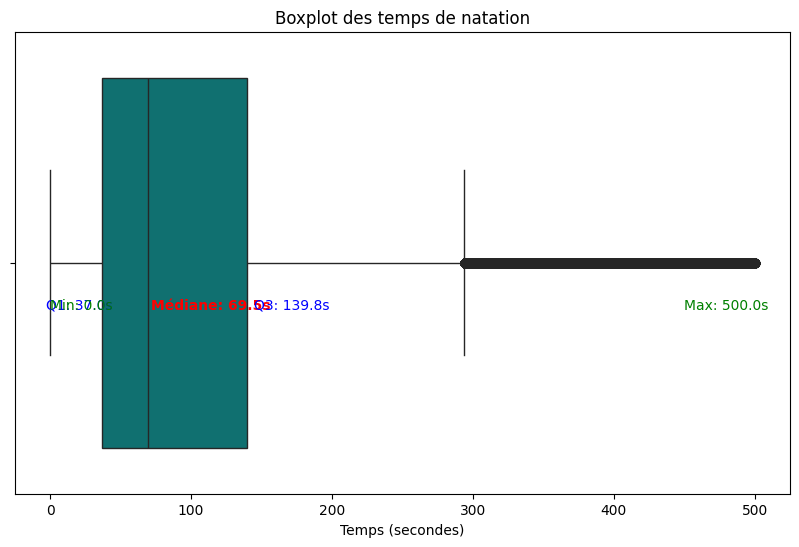

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

swim_times = df["SwimTimeSeconds"].dropna()
swim_times = swim_times[swim_times < 500]

plt.figure(figsize=(10,6))
sns.boxplot(x=swim_times, color="#008080")

median = np.median(swim_times)
q1 = np.percentile(swim_times, 25)
q3 = np.percentile(swim_times, 75)
min_val = swim_times.min()
max_val = swim_times.max()

plt.text(median + 2, 0.1, f"Médiane: {median:.1f}s", color="red", fontsize=10, weight="bold")
plt.text(q1 - 40, 0.1, f"Q1: {q1:.1f}s", color="blue", fontsize=10)
plt.text(q3 + 5, 0.1, f"Q3: {q3:.1f}s", color="blue", fontsize=10)
plt.text(min_val, 0.1, f"Min: {min_val:.1f}s", color="green", fontsize=10)
plt.text(max_val - 50, 0.1, f"Max: {max_val:.1f}s", color="green", fontsize=10)

plt.title("Boxplot des temps de natation")
plt.xlabel("Temps (secondes)")
plt.show()

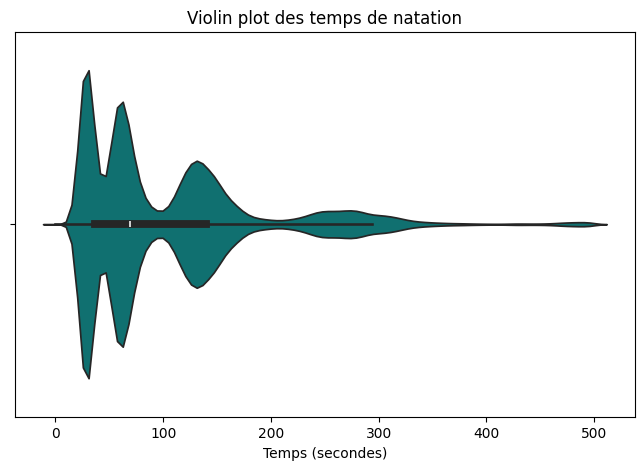

In [50]:
plt.figure(figsize=(8,5))
sns.violinplot(x=swim_times, color="#008080")
plt.title("Violin plot des temps de natation")
plt.xlabel("Temps (secondes)")
plt.show()

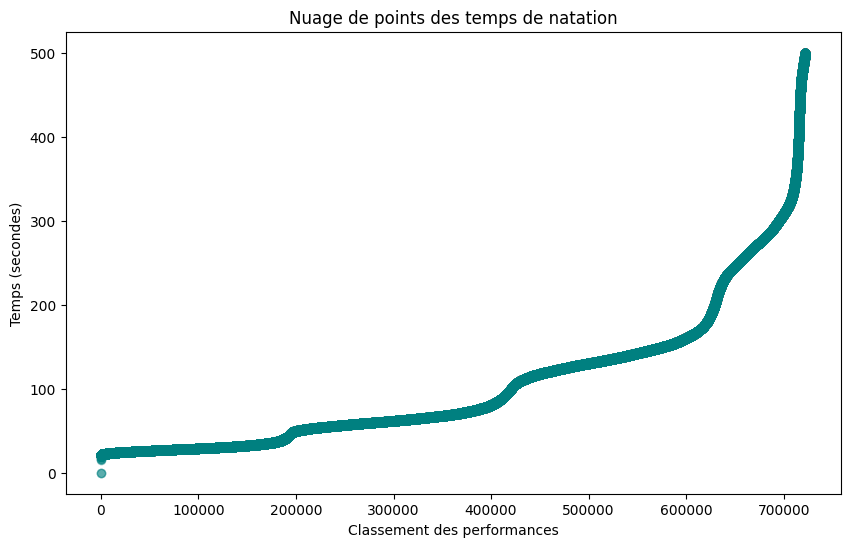

In [58]:
plt.figure(figsize=(10,6))
plt.scatter(range(len(swim_times)), sorted(swim_times), color="#008080", alpha=0.4)
plt.title("Nuage de points des temps de natation")
plt.xlabel("Classement des performances")
plt.ylabel("Temps (secondes)")
plt.show()

# Cumulative Histogram

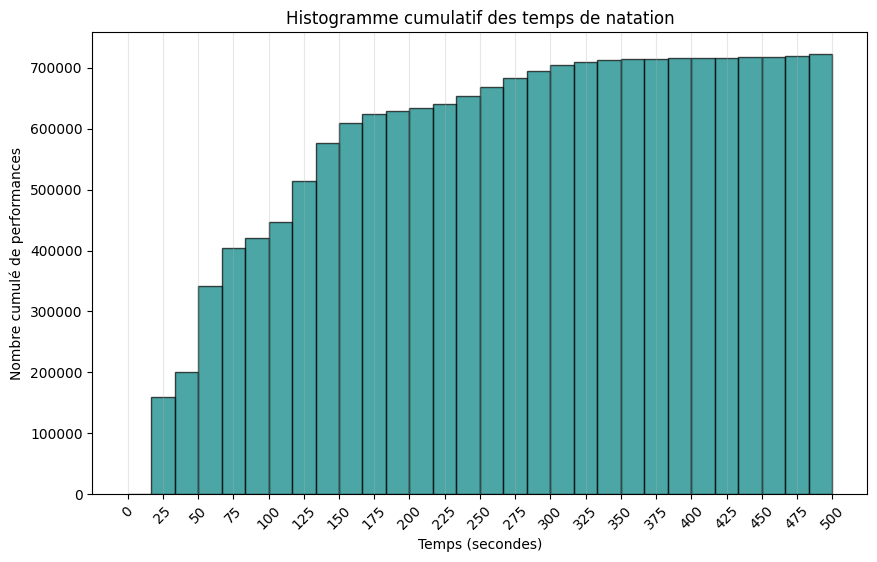

In [124]:
import matplotlib.pyplot as plt
import numpy as np

swim_times = df["SwimTimeSeconds"].dropna()
swim_times = swim_times[swim_times < 500]

plt.figure(figsize=(10,6))

plt.hist(swim_times, bins=30, cumulative=True, color="#008080",
         edgecolor="black", alpha=0.7)

plt.title("Histogramme cumulatif des temps de natation")
plt.xlabel("Temps (secondes)")
plt.ylabel("Nombre cumulé de performances")

plt.xticks(np.arange(0, 501, 25), rotation=45)  

plt.grid(axis="x", alpha=0.3)
plt.show()

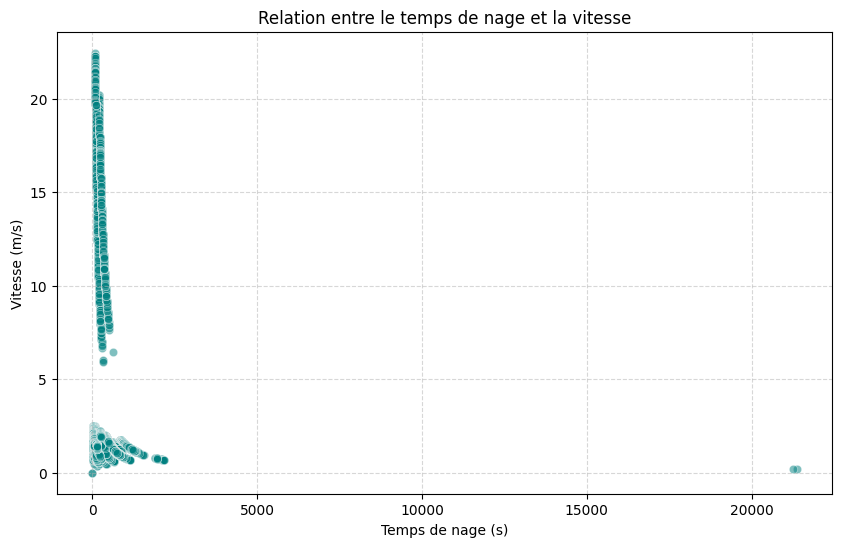

In [51]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='SwimTimeSeconds', y='Speed', data=df, alpha=0.5, color="#008080")
plt.title("Relation entre le temps de nage et la vitesse")
plt.xlabel("Temps de nage (s)")
plt.ylabel("Vitesse (m/s)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Countplot number of performances by sex

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1382442621.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette=palette_colors)


<Figure size 600x400 with 0 Axes>

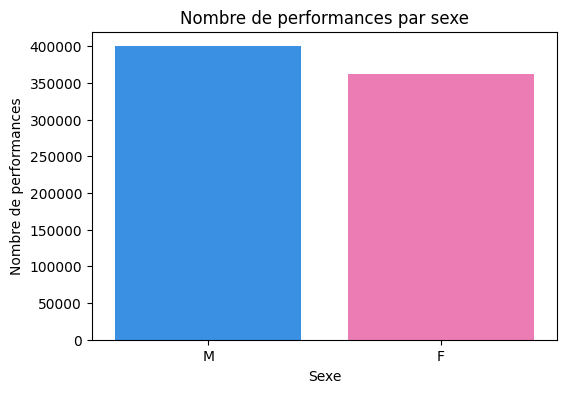

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

palette_colors = {"F": "#FF69B4", "M": "#1E90FF"}

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
palette_colors = {"F": "#FF69B4", "M": "#1E90FF"}

sns.countplot(x='Gender', data=df, palette=palette_colors)

plt.title("Nombre de performances par sexe")
plt.xlabel("Sexe")
plt.ylabel("Nombre de performances")
plt.show()

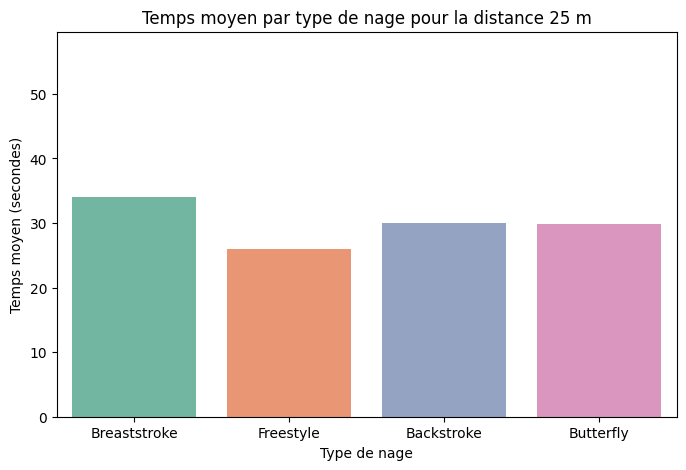

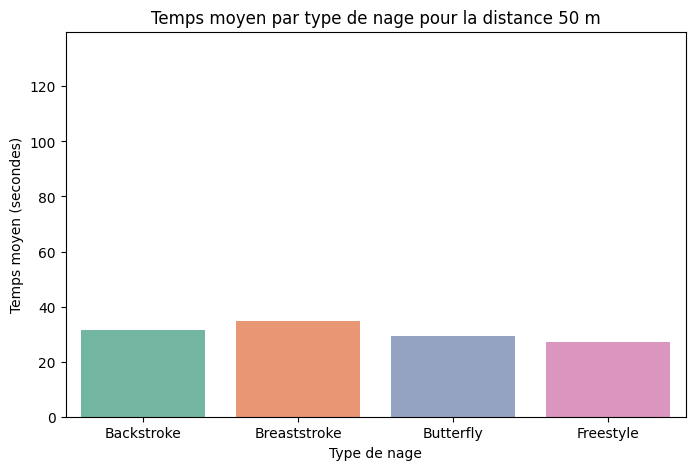

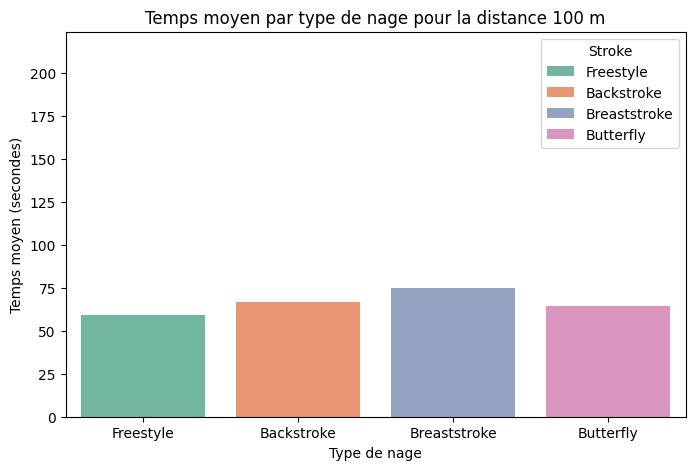

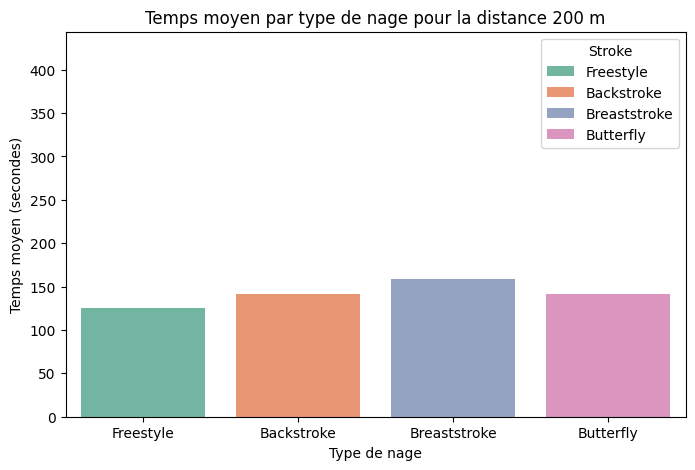

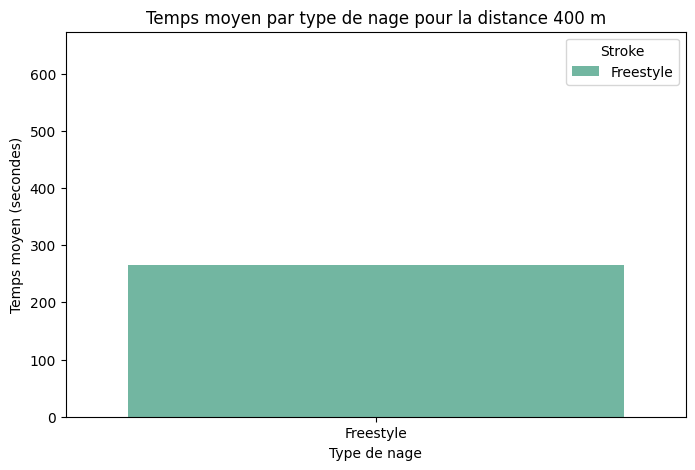

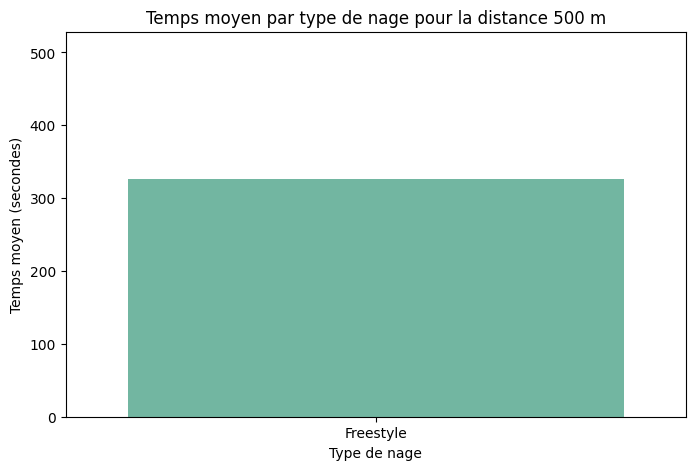

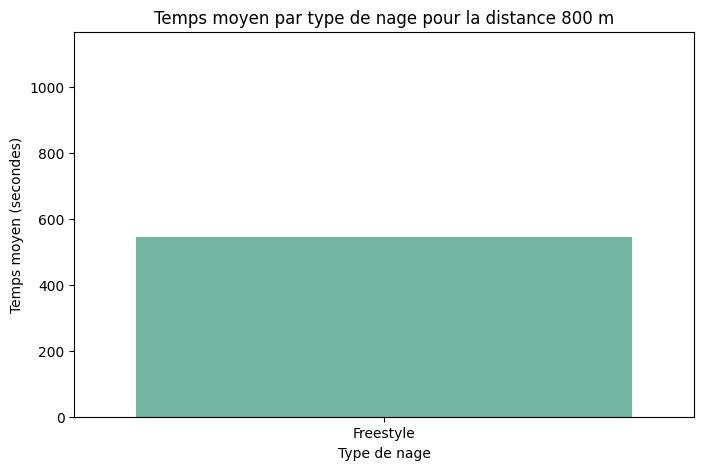

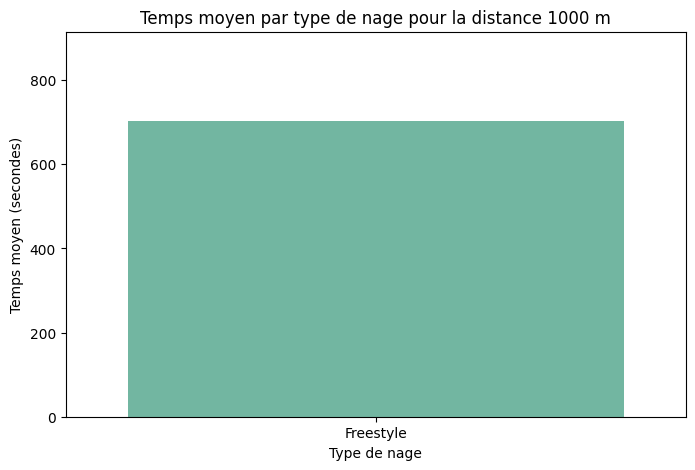

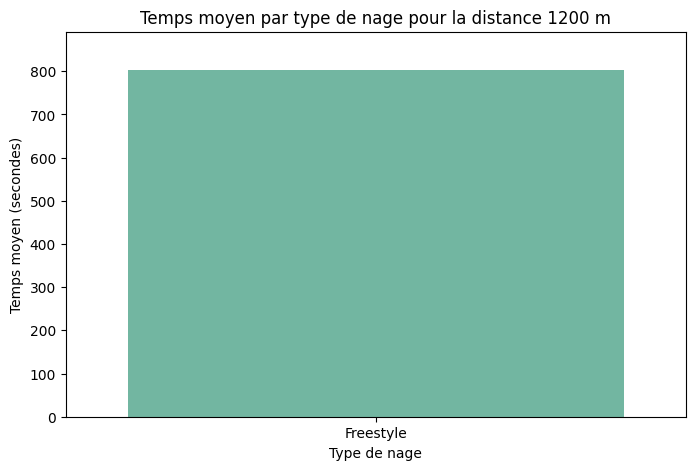

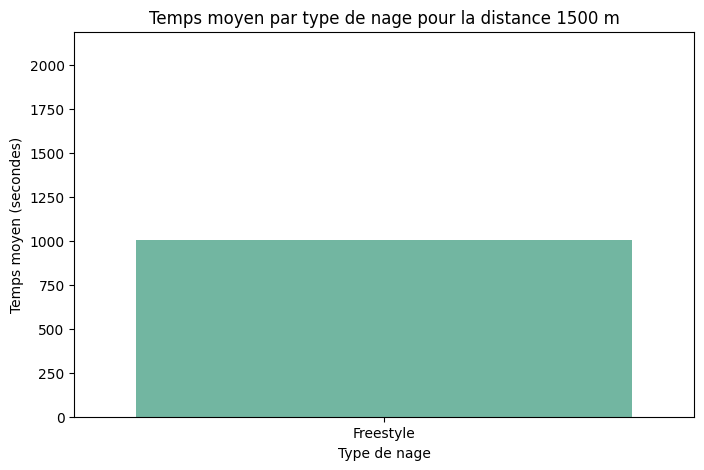

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/2145615213.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.barplot(


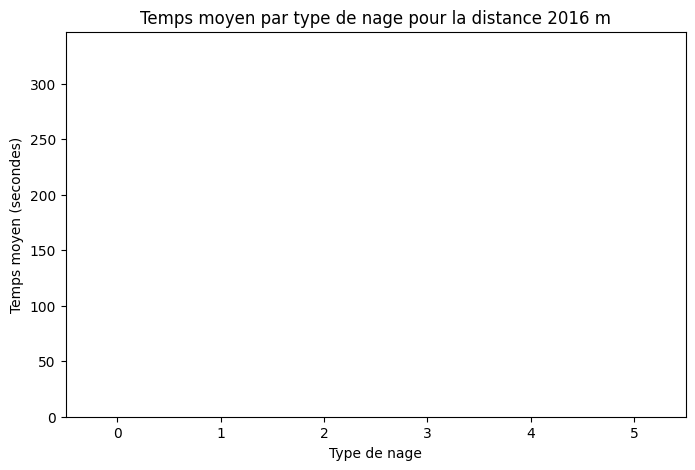

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/2145615213.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.barplot(


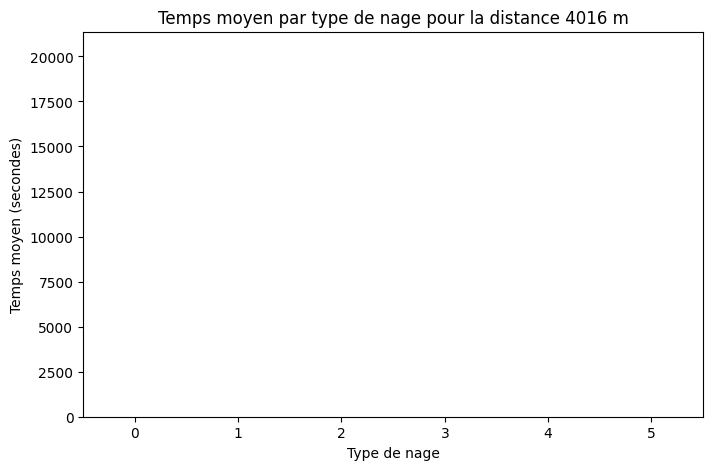

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_times = df[df['SwimTimeSeconds'].notna()]
distances = sorted(df_times['Distance'].unique())

for distance in distances:
    subset = df_times[df_times['Distance'] == distance]
    
    plt.figure(figsize=(8,5))
    sns.barplot(
        x='Stroke',
        y='SwimTimeSeconds',
        data=subset,
        hue='Stroke',    
        palette="Set2",
        errorbar=None,
        dodge=False      
    )
    
    plt.title(f"Temps moyen par type de nage pour la distance {distance} m")
    plt.xlabel("Type de nage")
    plt.ylabel("Temps moyen (secondes)")
    plt.ylim(0, subset['SwimTimeSeconds'].max() + 5)  
    plt.show()

# Bar Chart: Number of Performances per Club

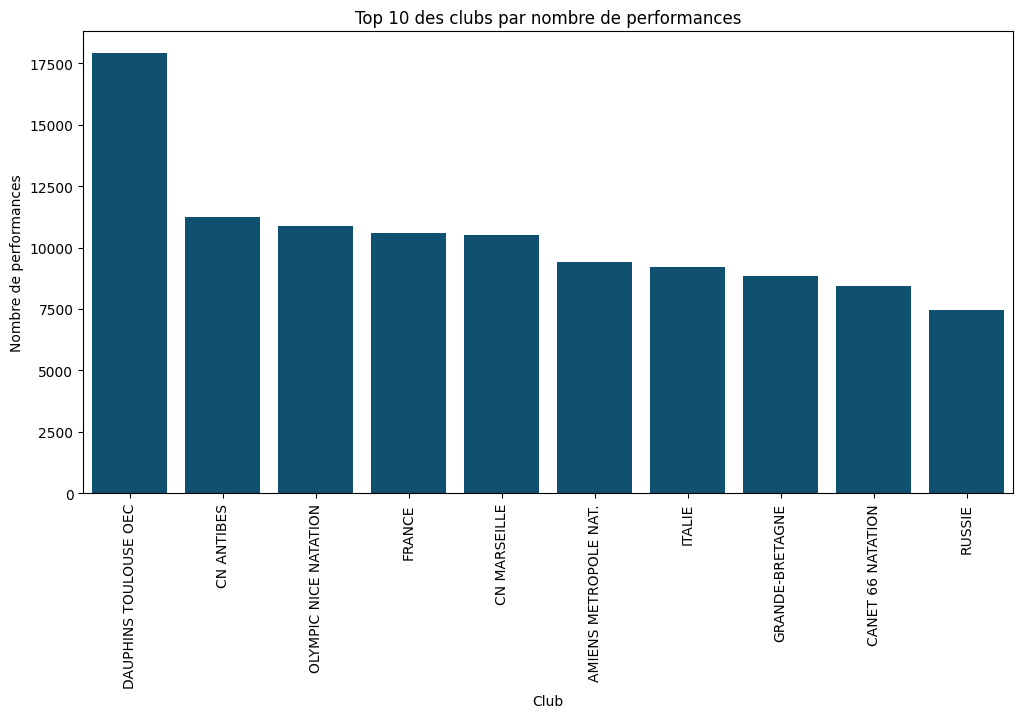

In [72]:
top_clubs = df['Club'].value_counts().nlargest(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_clubs.index, y=top_clubs.values, color="#005580")  
plt.title("Top 10 des clubs par nombre de performances")
plt.xlabel("Club")
plt.ylabel("Nombre de performances")
plt.xticks(rotation=90)
plt.show()

# Boxplot by Stroke Type

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/3875048533.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SwimTimeSeconds', y='Stroke', data=df, palette="Set2")


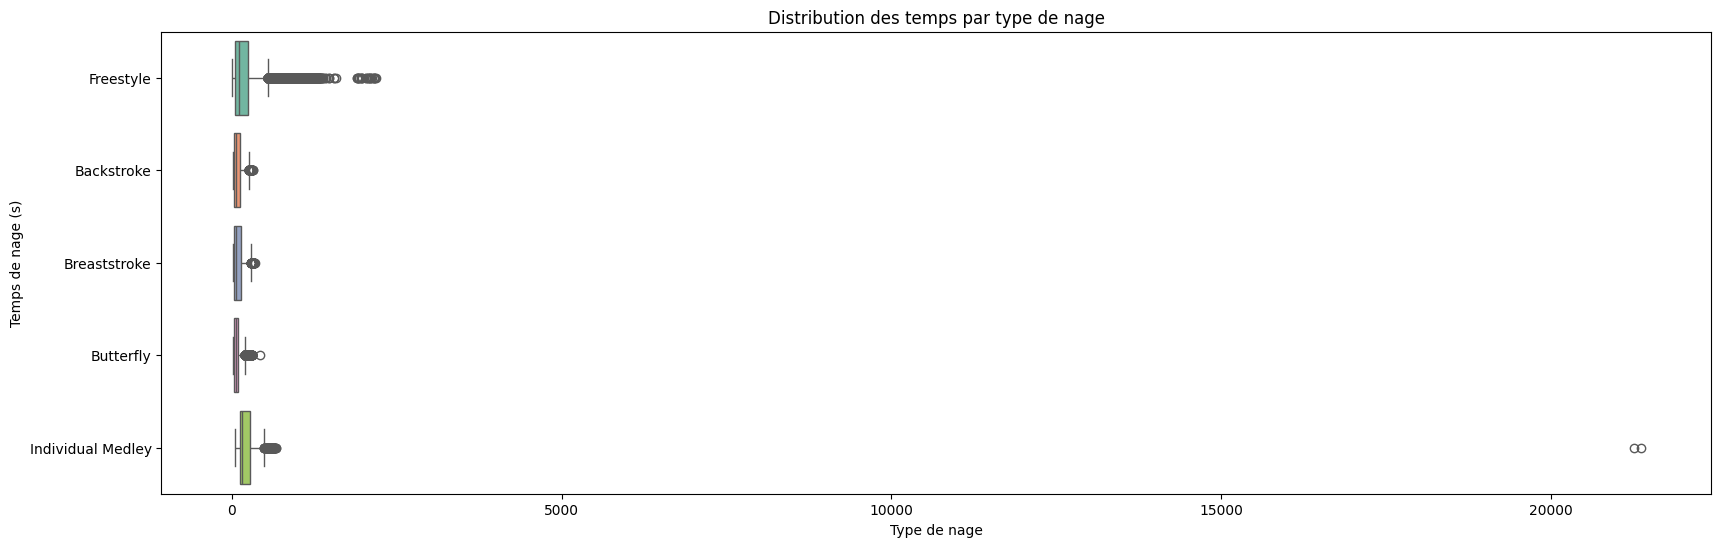

In [71]:
plt.figure(figsize=(20,6))
sns.boxplot(x='SwimTimeSeconds', y='Stroke', data=df, palette="Set2")
plt.title("Distribution des temps par type de nage")
plt.xlabel("Type de nage")
plt.ylabel("Temps de nage (s)")
plt.show()

# Line Plot of Swim Times by Stroke Type Over Time for a Sample of 5000

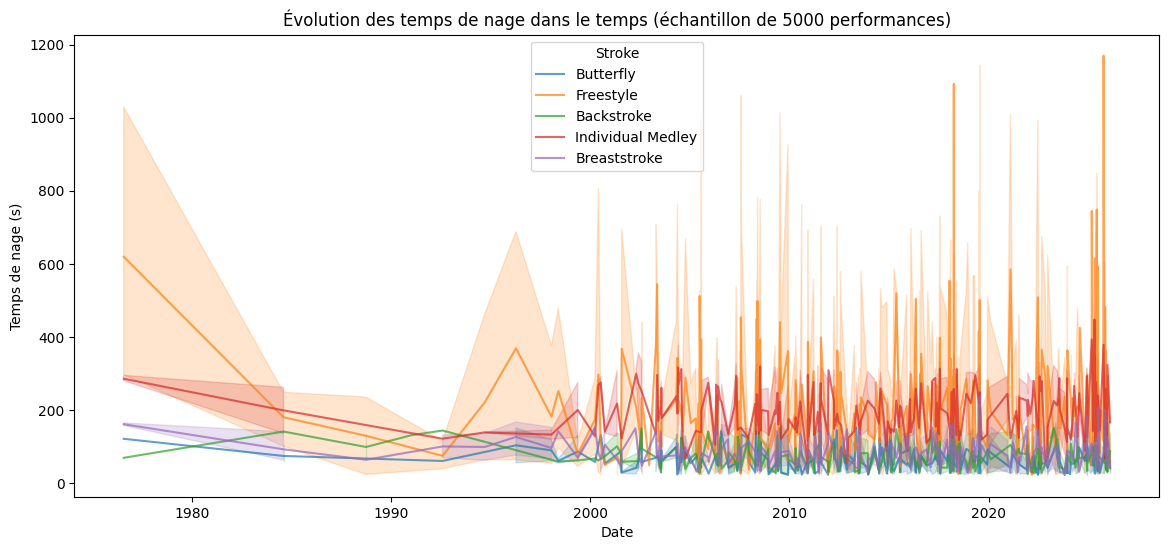

In [100]:
df['SwimDate'] = pd.to_datetime(df['SwimDate'])
plt.figure(figsize=(14,6))
sns.lineplot(x='SwimDate', y='SwimTimeSeconds', data=df.sample(5000), hue='Stroke', alpha=0.7)
plt.title("Évolution des temps de nage dans le temps (échantillon de 5000 performances)")
plt.xlabel("Date")
plt.ylabel("Temps de nage (s)")
plt.legend(title='Stroke')
plt.show()

# Heatmap of Average Swim Times by Distance and Stroke Type

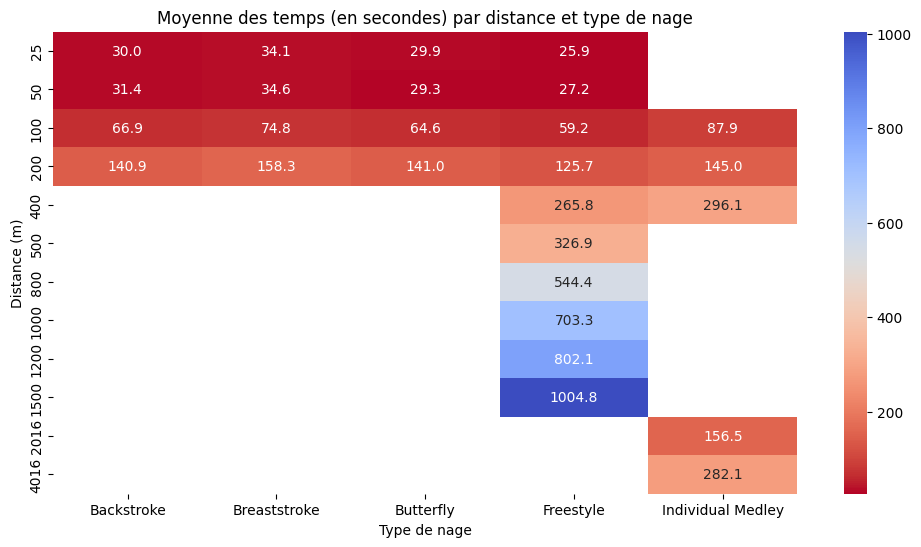

In [102]:
pivot = df.pivot_table(values='SwimTimeSeconds', index='Distance', columns='Stroke', aggfunc='mean')

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="coolwarm_r")
plt.title("Moyenne des temps (en secondes) par distance et type de nage")
plt.xlabel("Type de nage")
plt.ylabel("Distance (m)")
plt.show()

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


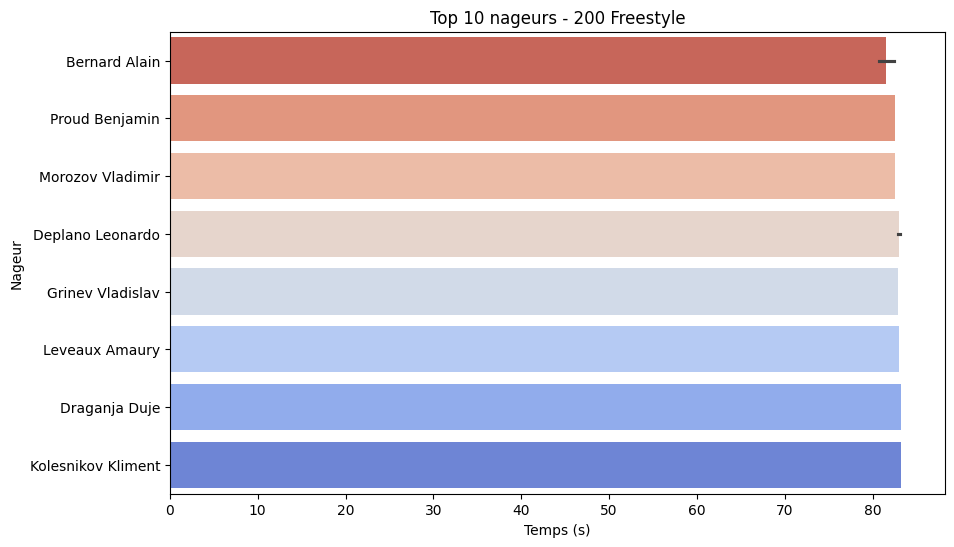

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


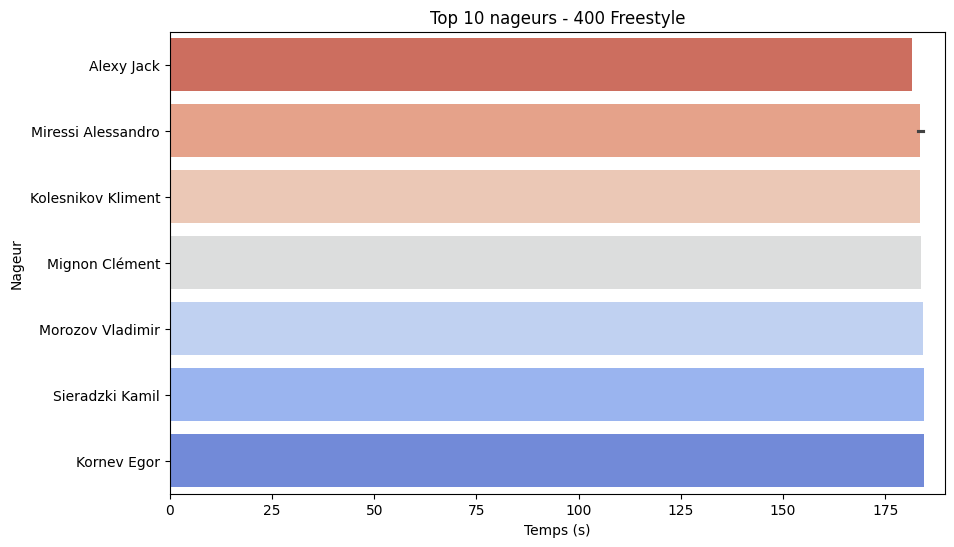

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


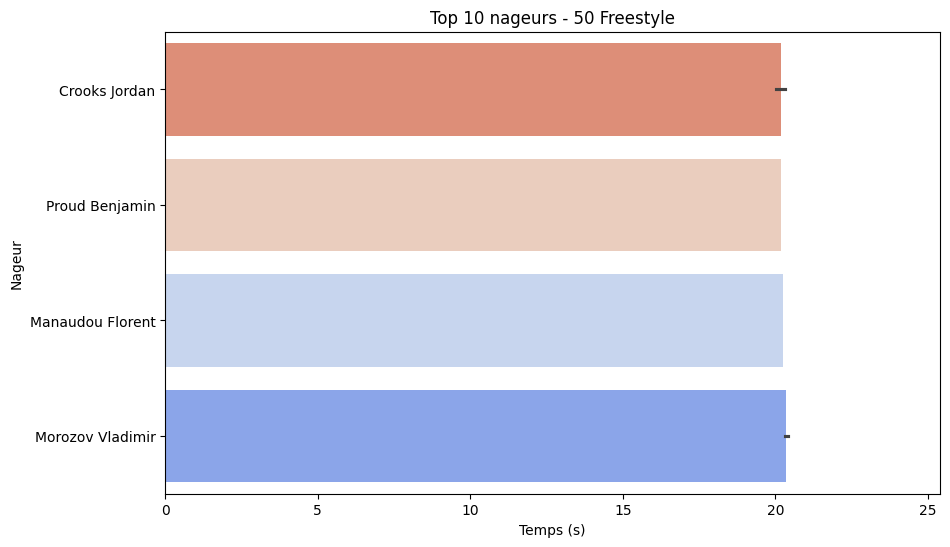

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


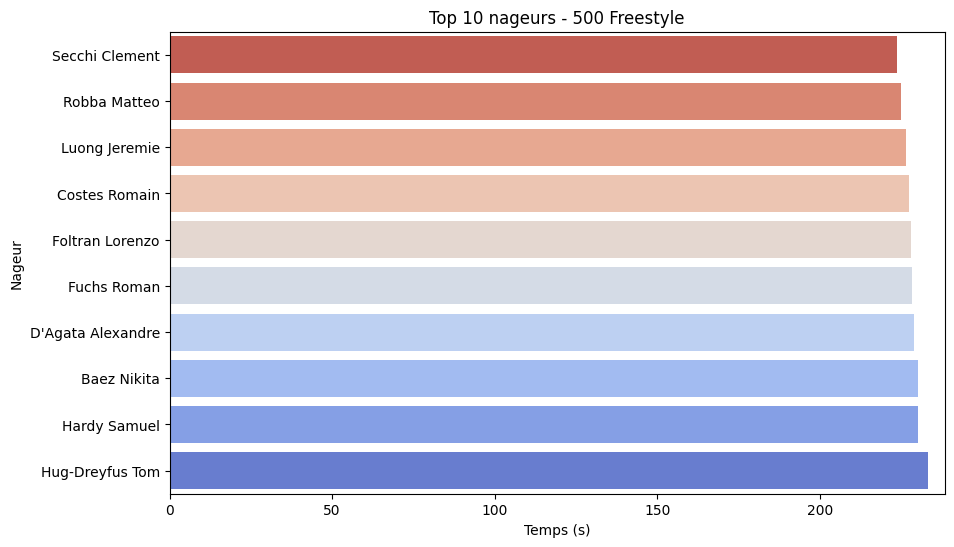

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


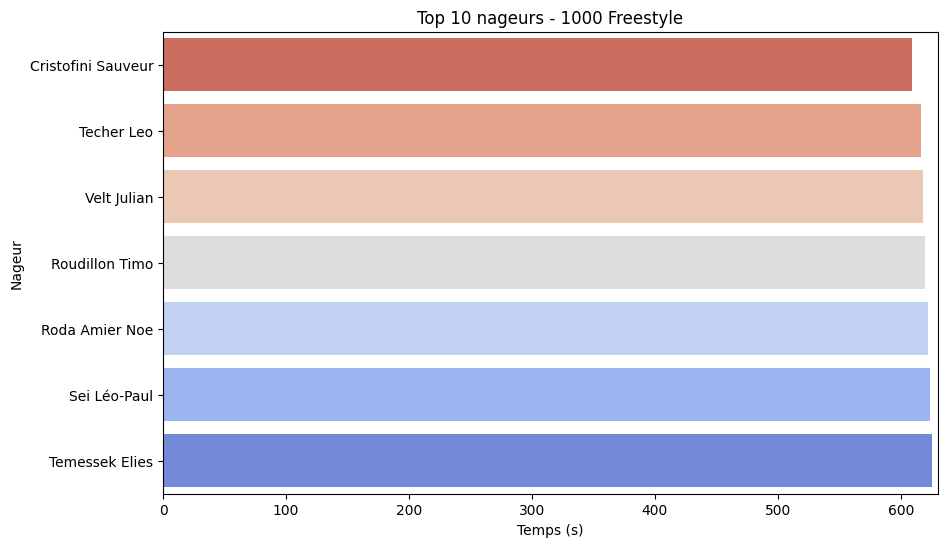

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


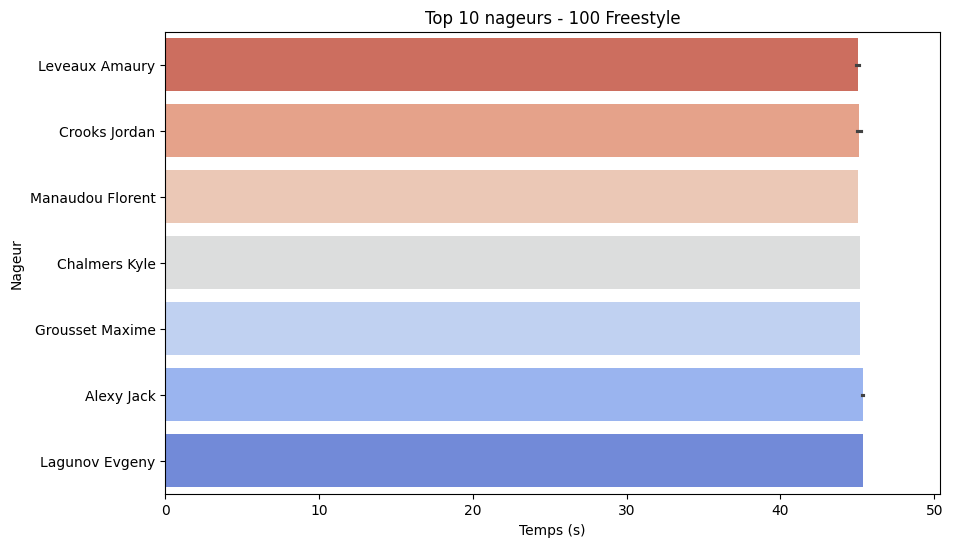

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


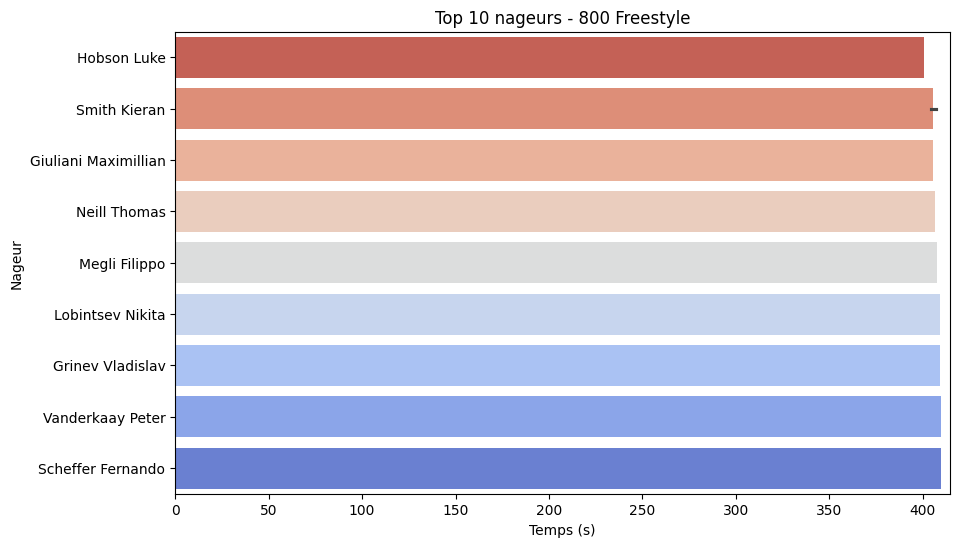

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


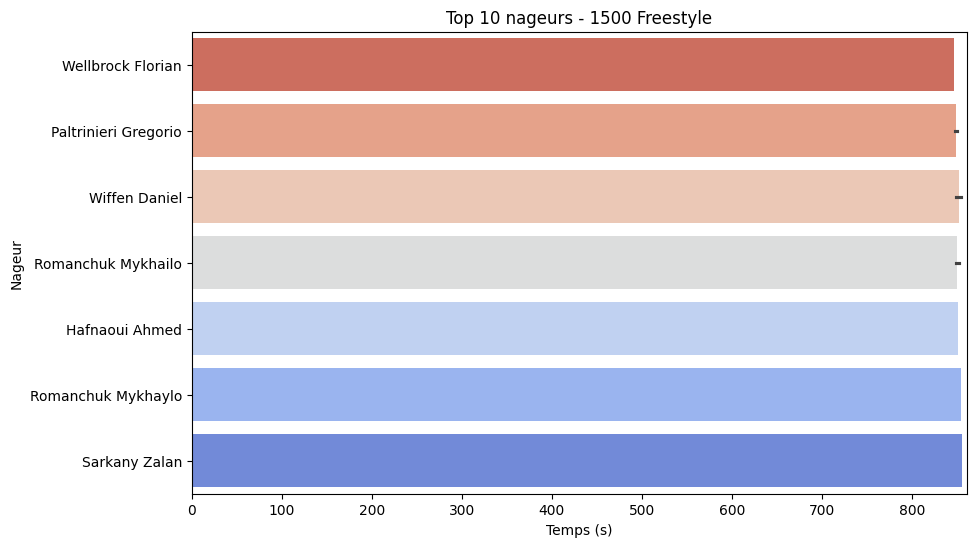

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


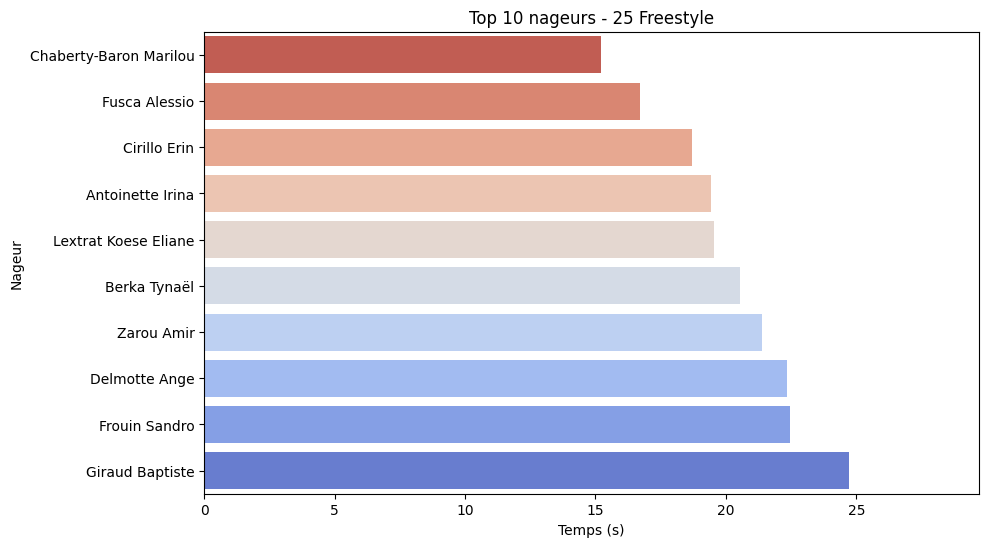

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


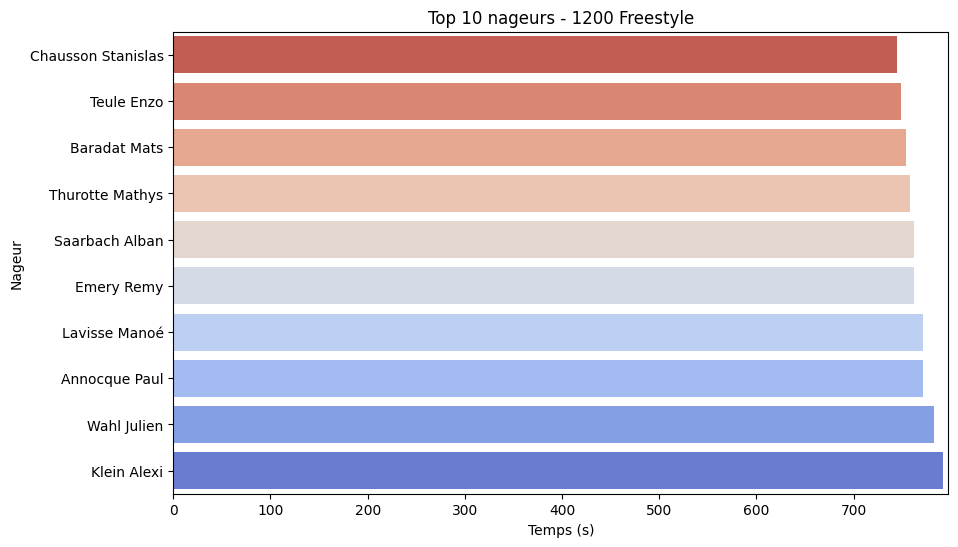

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


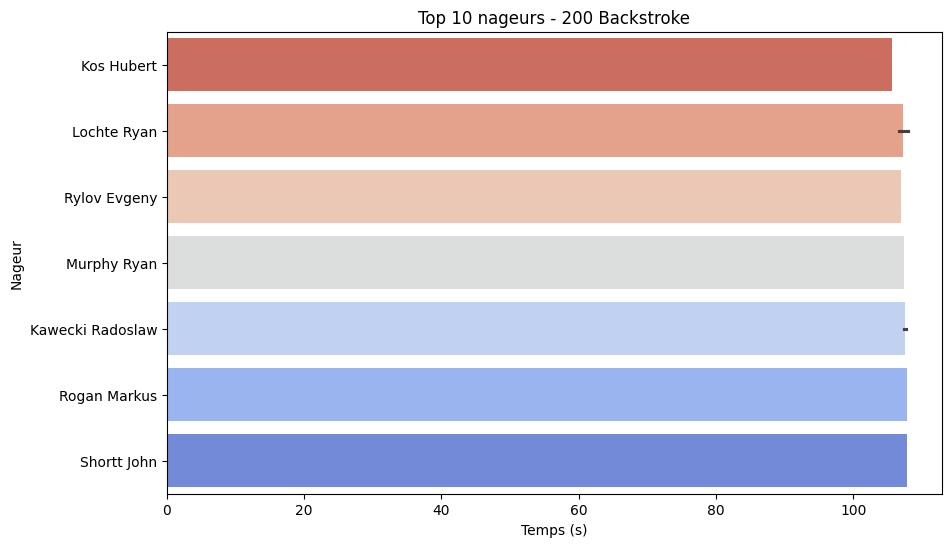

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


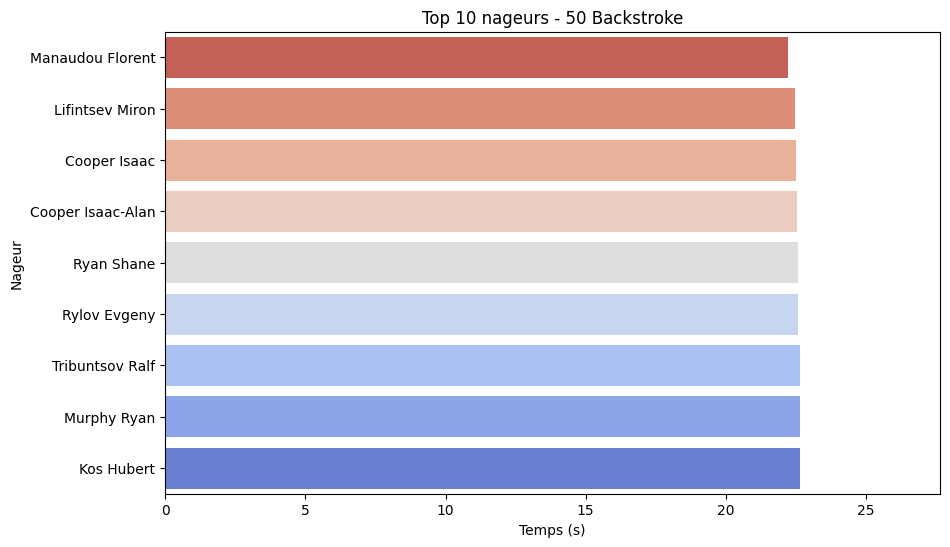

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


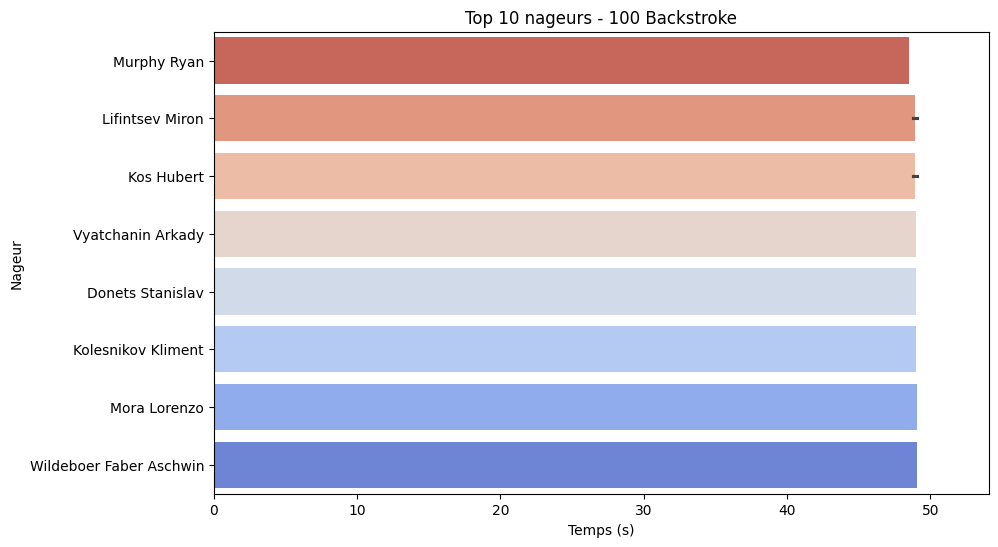

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


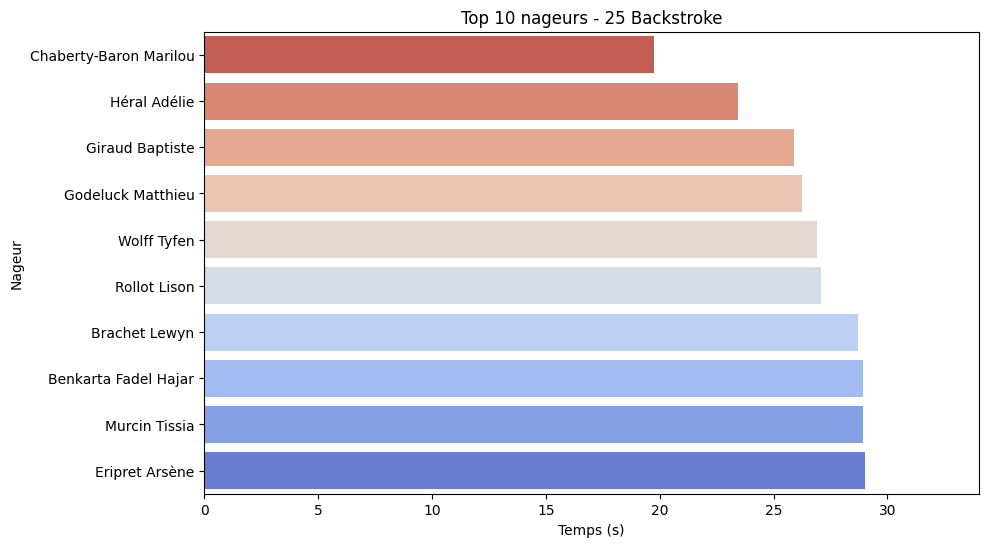

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


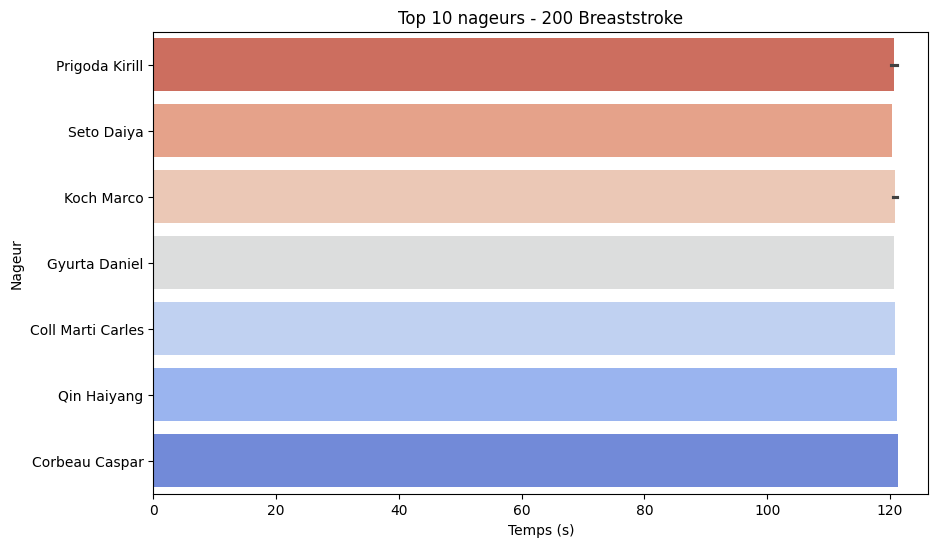

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


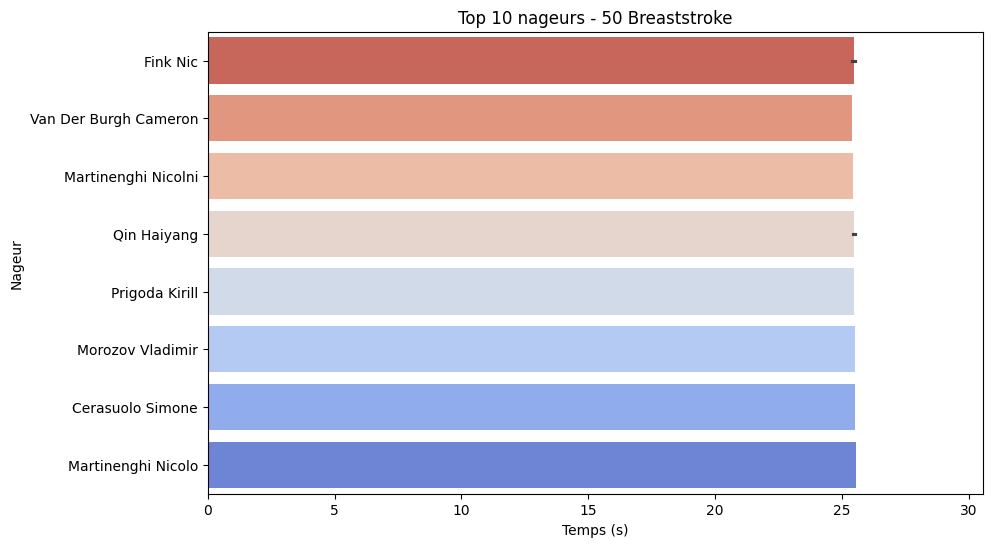

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


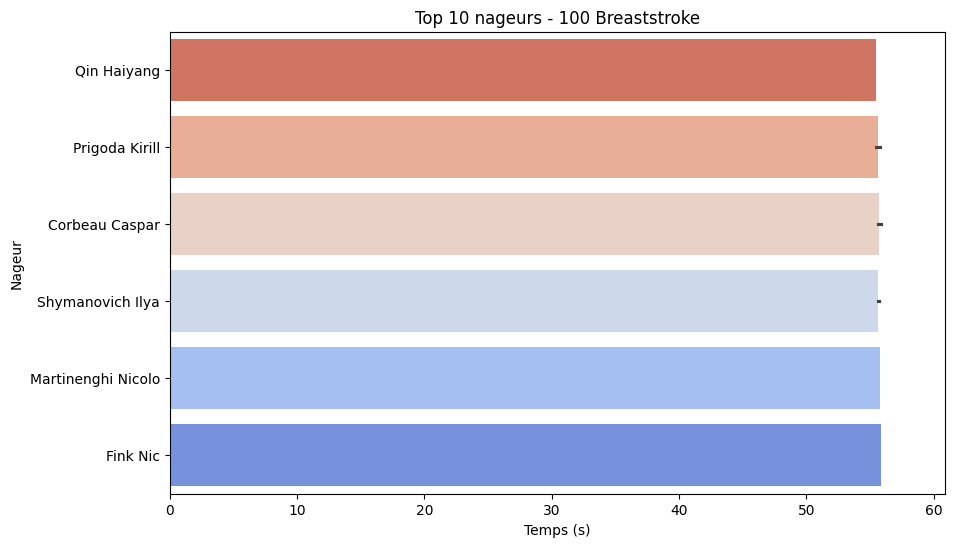

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


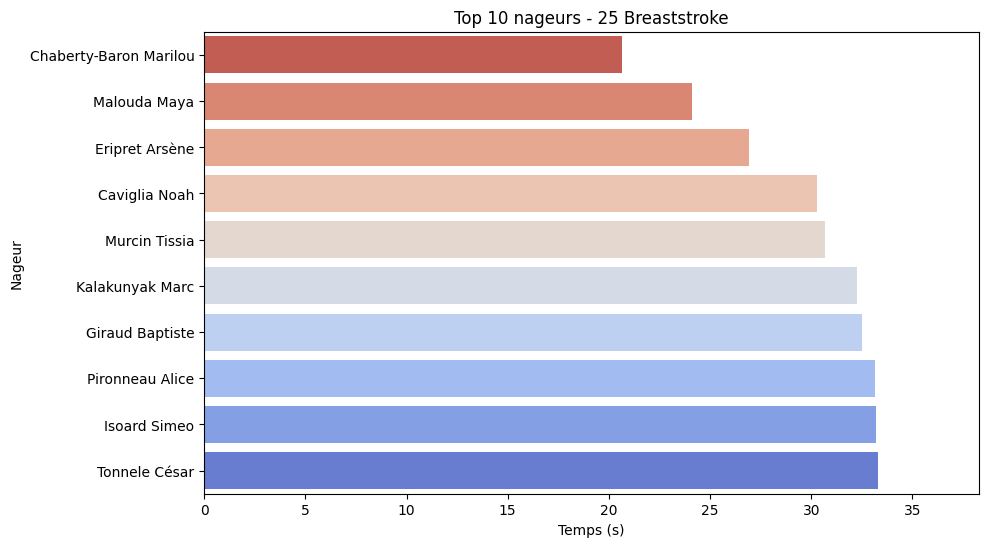

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


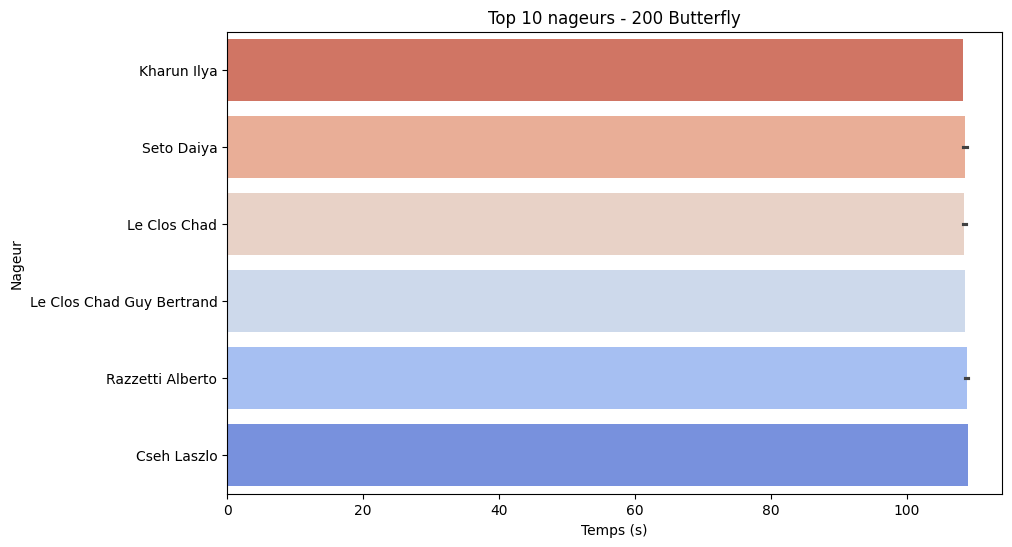

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


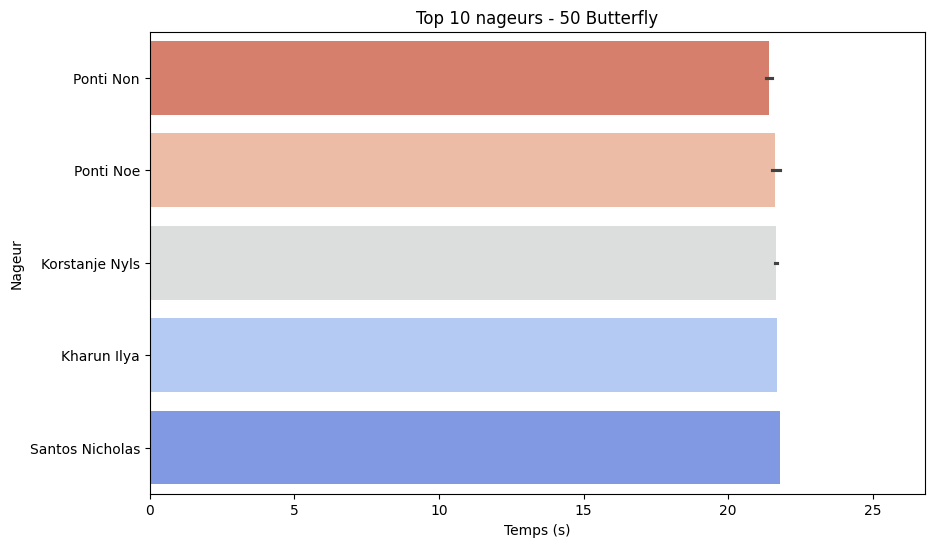

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


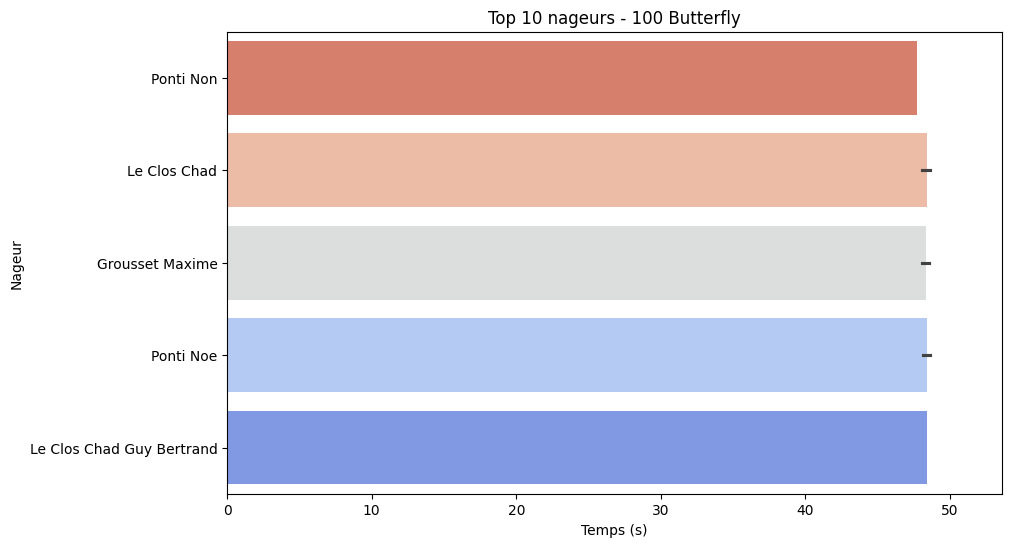

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


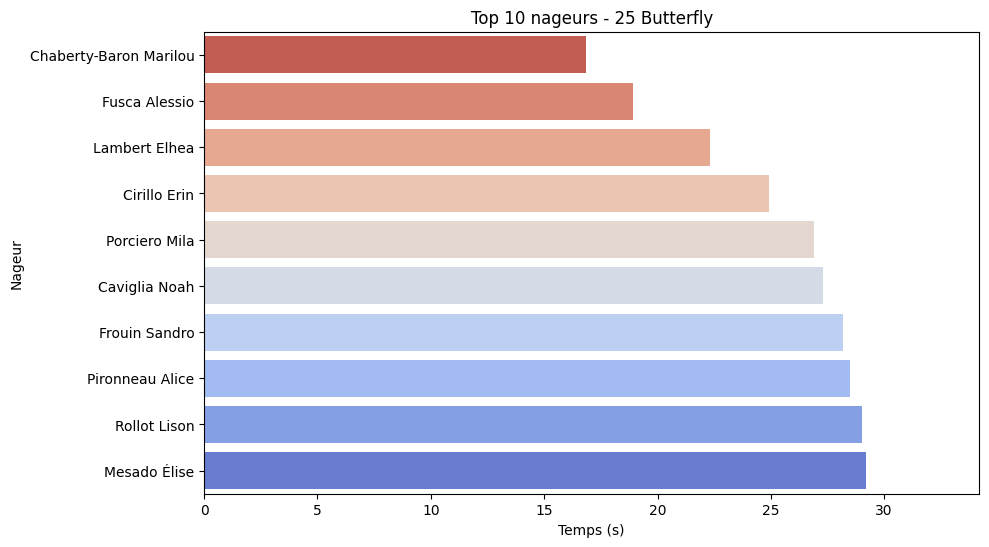

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


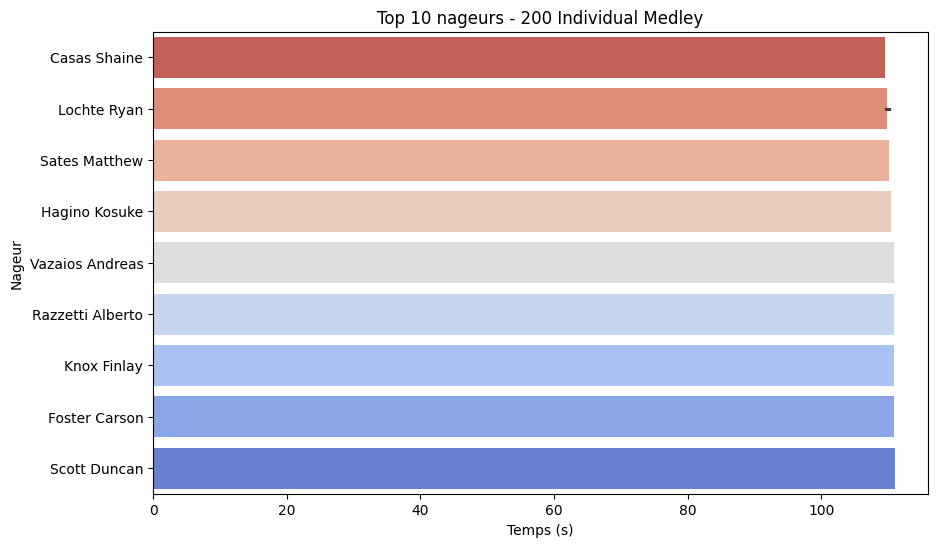

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


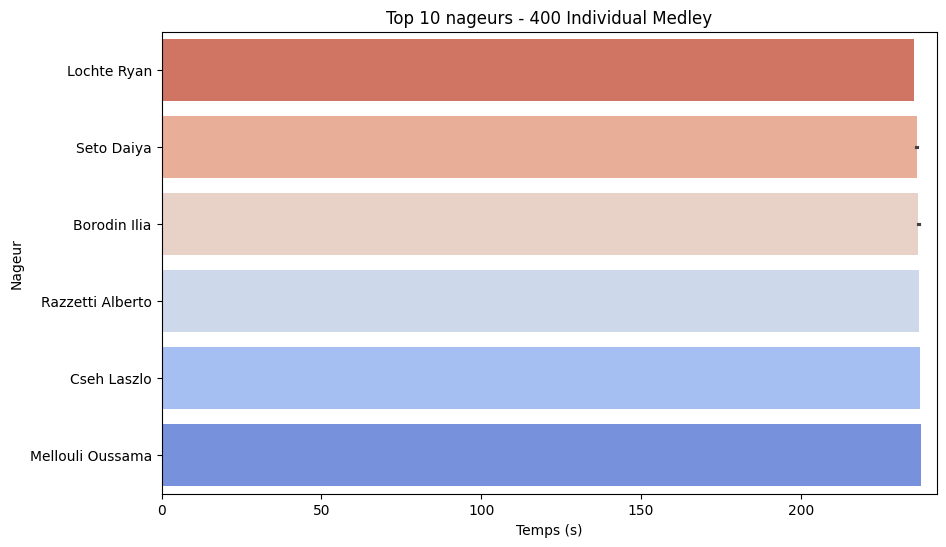

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


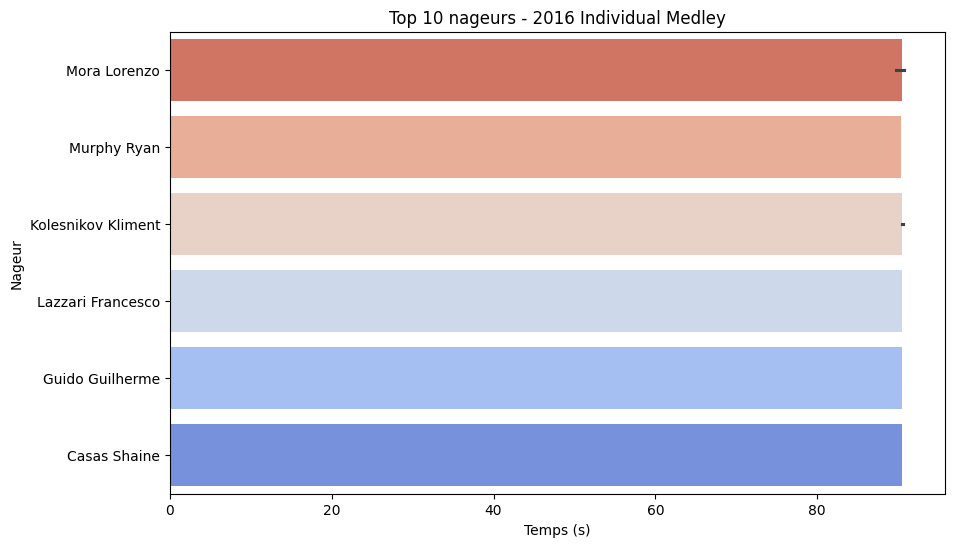

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


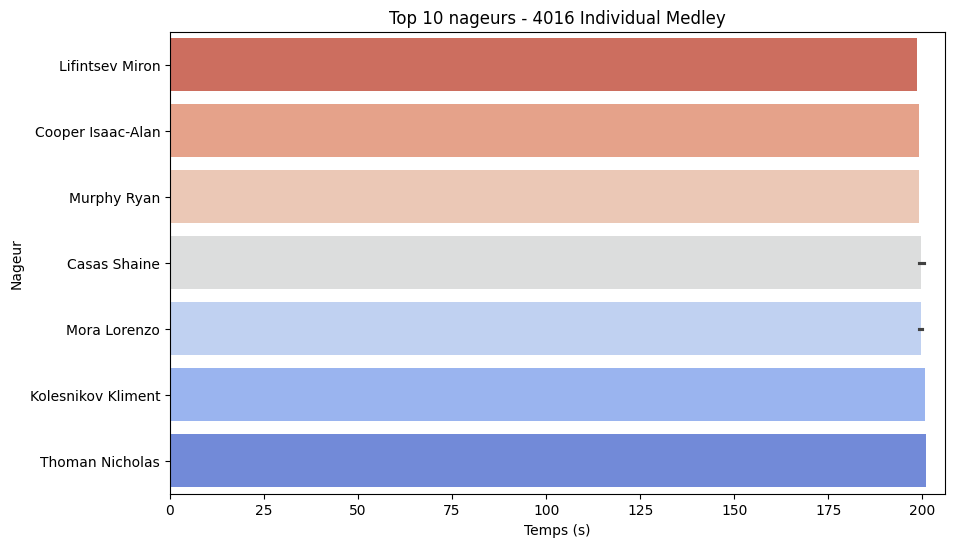

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2042/1689411971.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


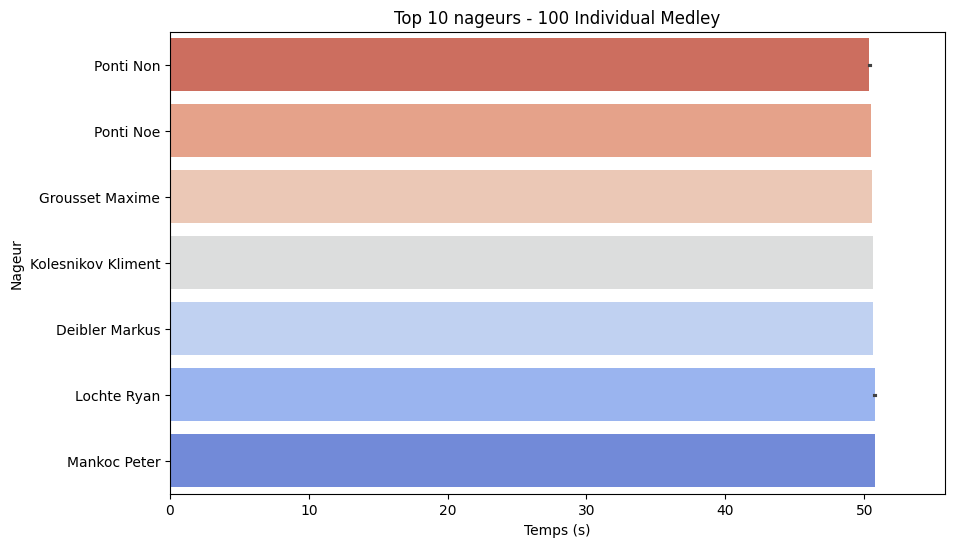

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_clean = df[df['SwimTimeSeconds'].notna() & (df['SwimTimeSeconds'] > 0)]

strokes = df_clean['Stroke'].unique()
distances = df_clean['Distance'].unique()

for stroke in strokes:
    for distance in distances:
        subset = df_clean[(df_clean['Stroke'] == stroke) & 
                          (df_clean['Distance'] == distance) & 
                          (df_clean['SwimTimeSeconds'] > 0)]
        if subset.empty:
            continue
        
        subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
        
        top10 = subset.nsmallest(10, 'SwimTimeSeconds')
        
        plt.figure(figsize=(10,6))
        sns.barplot(
            x='SwimTimeSeconds', 
            y='SwimmerName', 
            data=top10, 
            palette="coolwarm_r", 
            orient='h'
        )
        plt.title(f"Top 10 nageurs - {distance} {stroke}")
        plt.xlabel("Temps (s)")
        plt.ylabel("Nageur")
        plt.xlim(0, top10['SwimTimeSeconds'].max() + 5)
        plt.show()